In [6]:
# Load dependencies
import pandas as pd
import numpy as np

# machine learning
import keras
import ml_edu.experiment
import ml_edu.results

# data visualization
import plotly.express as px
import nbformat

In [7]:
# Read the dataset
chicago_taxi_dataframe = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

# updates daataframe to use specific columns.
training_df = chicago_taxi_dataframe.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]
training_df.head(200)

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


In [8]:
# View dataset statistics
print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.describe(include='all')

# What is the maximum fare?
# max_fare = training_df['FARE'].max()
max_fare = training_df['FARE'].describe()['max']
print(f"What is the maximum fare?  Answer: ${max_fare:.2f}")


# What is the mean distance across all trips?
# mean_distance = training_df['TRIP_MILES'].mean()
mean_distance = training_df['TRIP_MILES'].describe()['mean']
print(f"What is the mean distance across all trips? Answer: {mean_distance:.4f}")

# How many cabs companies are in the dataset?
# num_unique_companies = len(training_df['COMPANY'].unique())
num_unique_companies = training_df['COMPANY'].describe()['unique']
print(f"How many cabs companies are in the dataset? Answer: {num_unique_companies}")


# What is the most frequent payment type?
# most_freq_payment_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
most_freq_payment_type = training_df['PAYMENT_TYPE'].describe()['top']
print(f"What is the most frequent payment type? Answer: {most_freq_payment_type}")

# Are any feature missing data?
missing_values = training_df.isnull().sum().sum()
print(f"Are any feature missing data? Answer:", "No" if missing_values == 0 else "Yes")


Total number of rows: 31694


What is the maximum fare?  Answer: $159.25
What is the mean distance across all trips? Answer: 8.2895
How many cabs companies are in the dataset? Answer: 31
What is the most frequent payment type? Answer: Credit Card
Are any feature missing data? Answer: No


In [9]:
# View correlation matrix
print(training_df.corr(numeric_only=True))

              TRIP_MILES  TRIP_SECONDS      FARE  TIP_RATE
TRIP_MILES      1.000000      0.800855  0.975344 -0.049594
TRIP_SECONDS    0.800855      1.000000  0.830292 -0.084294
FARE            0.975344      0.830292  1.000000 -0.070979
TIP_RATE       -0.049594     -0.084294 -0.070979  1.000000


In [10]:
# View pairplot
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])


In [11]:
# Train Model
# Define ML functions
def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
    """Create and compile a simple linear regression model."""
    # Describe the topography of the model
    # The topography of a simple linear regression model
    # is a single node in a single layer.
    inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
    concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
    outputs = keras.layers.Dense(units=1)(concatenated_inputs)
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile the model topography into code that Keras can efficiently
    # execute. Configure training to minimize the model's mean squared error.
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
        loss="mean_squared_error",
        metrics=metrics
        )
    return model
def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
    ) -> ml_edu.experiment.Experiment:
    """Train the model by feeding it data"""
    features = {name: dataset[name].values for name in settings.input_features}
    label = dataset[label_name].values
    history = model.fit(
        x=features,
        y=label,
        batch_size=settings.batch_size,
        epochs=settings.number_epochs
        )
    return ml_edu.experiment.Experiment(
        name=experiment_name,
        settings=settings,
        model=model,
        epochs=history.epoch,
        metrics_history=pd.DataFrame(history.history),
    )


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 131.8126 - rmse: 11.4810
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 34.6462 - rmse: 5.8861
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 19.3057 - rmse: 4.3938
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 17.6994 - rmse: 4.2071
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 16.4145 - rmse: 4.0515
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 15.4777 - rmse: 3.9342
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.8265 - rmse: 3.8505
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.4150 - rmse: 3.7967
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.2022 - rmse: 3.7686
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.1080 - rmse: 3.7561
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.0656 - rmse: 3.7504
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.0447 - rmse: 3.7476

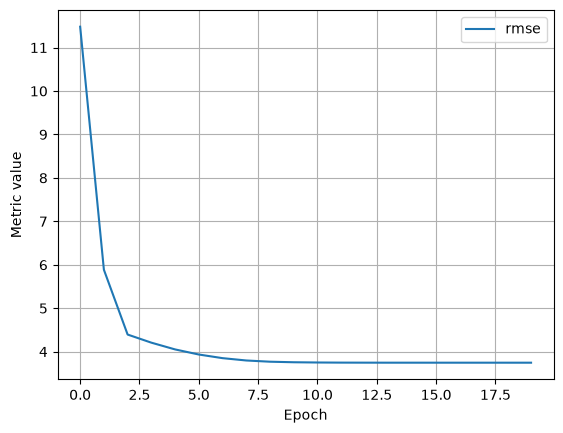

In [12]:
# Experiment 1 (Train a model with single features)
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'FARE', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, training_df, 'FARE')
    


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 48.9366 - rmse: 6.9955
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.1057 - rmse: 6.9358
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47.3484 - rmse: 6.8810
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47.5343 - rmse: 6.8945
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.3711 - rmse: 6.9549
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 48.1003 - rmse: 6.9354
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.7842 - rmse: 6.9846
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.3156 - rmse: 6.9509
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.2504 - rmse: 6.9462
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.1064 - rmse: 6.9359
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.2822 - rmse: 6.9485
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47.6516 - rmse: 6.9030
E

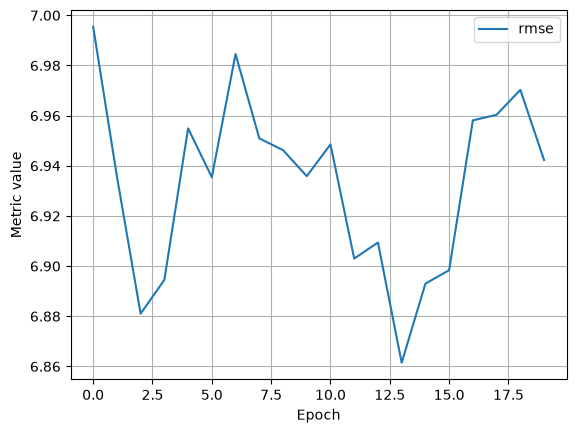

In [13]:
# Experiment 2 (Experiment 1: Increase the learning rate to 1.0 (batch size at 50))
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=1.0,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 700.7687 - rmse: 26.4720
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 662.9327 - rmse: 25.7475
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 626.2231 - rmse: 25.0245
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 590.5350 - rmse: 24.3009
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 555.9579 - rmse: 23.5788
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 522.3406 - rmse: 22.8548
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 490.0709 - rmse: 22.1375
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 458.6324 - rmse: 21.4157
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 428.3039 - rmse: 20.6955
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 399.1053 - rmse: 19.9776
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 371.0236 - rmse: 19.2620
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 34

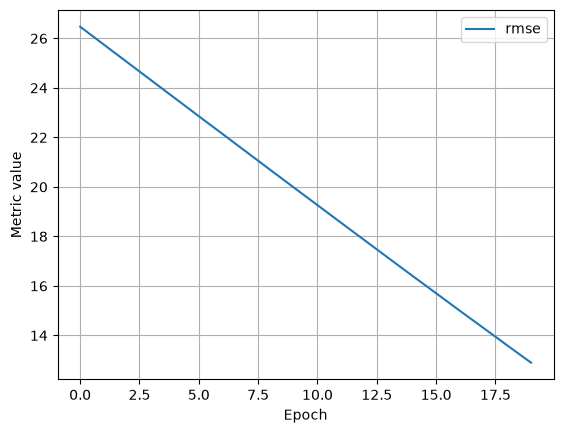

In [14]:
# Experiment 2(Experiment 2: Decrease the learning rate to 0.0001 (batch size at 50)) 
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.0001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 562.6883 - rmse: 23.7211
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 527.7267 - rmse: 22.9723
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 494.3871 - rmse: 22.2348
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 462.2050 - rmse: 21.4990
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 431.3811 - rmse: 20.7697
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 401.4388 - rmse: 20.0359
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 372.5671 - rmse: 19.3020
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 344.9810 - rmse: 18.5737
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 318.5161 - rmse: 17.8470
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 293.0181 - rmse: 17.1178
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 268.7589 - rmse: 16.3939
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 245.6434 - rmse: 15.6730
E

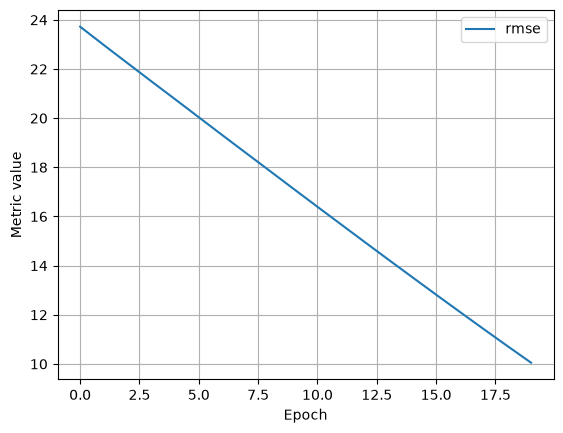

In [15]:
# Experiment 2(Experiment 3: Increase the batch size to 500 (learning rate at 0.001))
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=500,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 89.9480 - rmse: 9.4841
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 56.7651 - rmse: 7.5343
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 34.8666 - rmse: 5.9048
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 21.6072 - rmse: 4.6483
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 15.5798 - rmse: 3.9471
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 13.4973 - rmse: 3.6739
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 12.8163 - rmse: 3.5800
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12.4708 - rmse: 3.5314
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 12.2841 - rmse: 3.5049
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 12.1883 - rmse: 3.4912
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 12.1420 - rmse: 3.4845
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 12.1207 - rmse: 3.4815
E

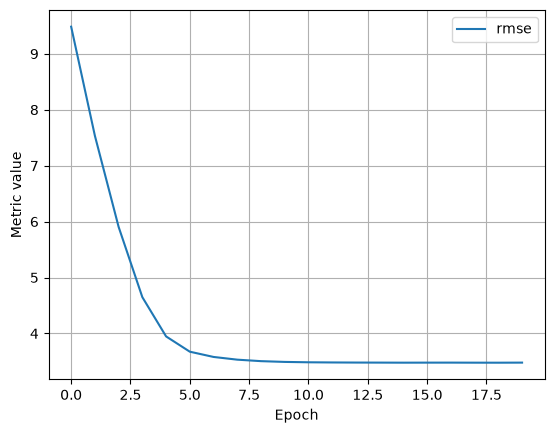

In [16]:
# Train a model with two features
# Experiment 3
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES', 'TRIP_MINUTES']
)

training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS'] / 60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = create_model(settings_3, metrics)

experiment_3 = train_model('two_feature', model_3, training_df, 'FARE', settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, training_df, 'FARE')

In [17]:
# Model 3 weight, bias
weightBias = model_3.get_weights()
weightBias

[array([[2.0245714 ],
        [0.14408967]], dtype=float32),
 array([3.8182285], dtype=float32)]

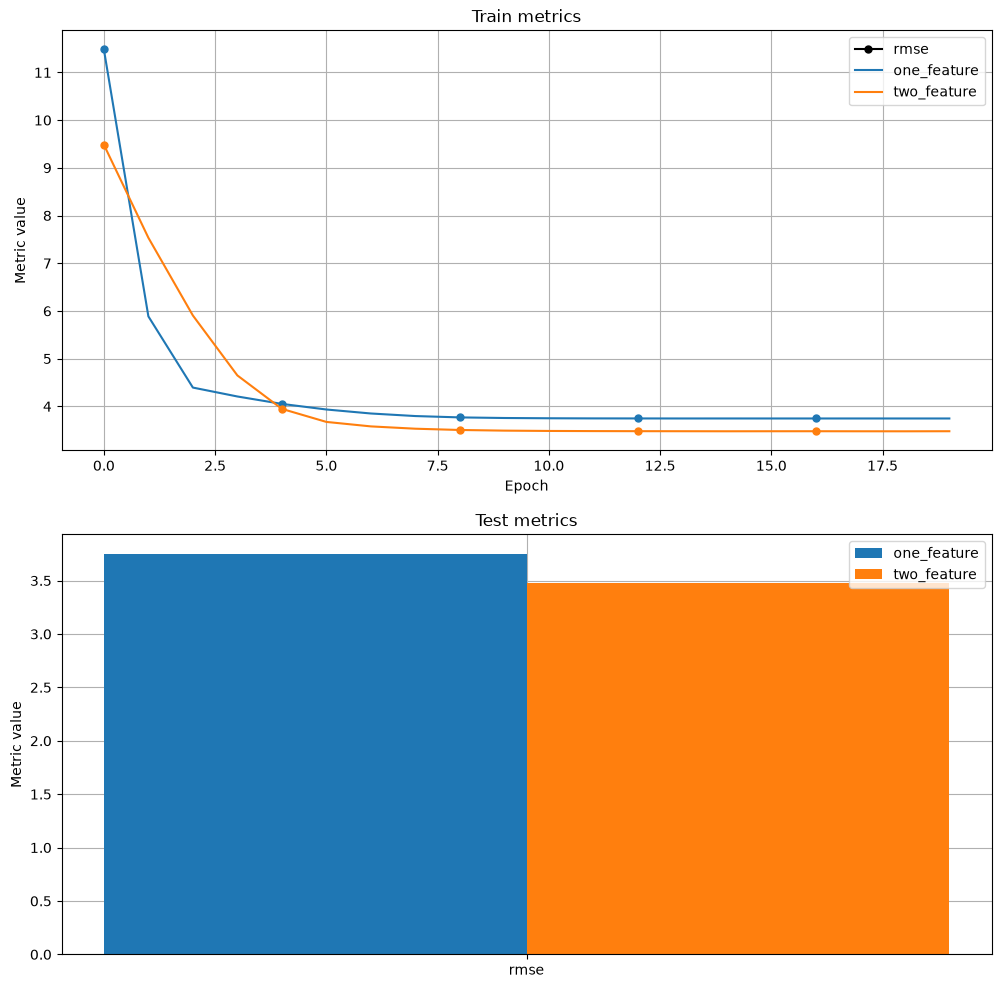

In [18]:
# Compare Experiments
ml_edu.results.compare_experiment([experiment_1, experiment_3], ['rmse'], training_df, training_df['FARE'].values)

In [ ]:
# Use the model to make predictions
#  Define functions to make predictions
def format_currency(x):
    return "${:.2f}".format(x)

def build_batch(df, batch_size):
    batch = df.sample(n=batch_size).copy()
    batch.set_index(np.arange(batch_size), inplace=True)
    return batch

def predict_fare(model, df, features, label, batch_size=50):
    batch = build_batch(df, batch_size)
    predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})
    
    data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [], 
            features[0]: [], features[1]: []}
    for i in range(batch_size):
        predicted = predicted_values[i][0]
        observed = batch.at[i, label]
        data["PREDICTED_FARE"].append(format_currency(predicted))
        data["OBSERVED_FARE"].append(format_currency(observed))
        data["L1_LOSS"].append(format_currency(abs(observed-predicted)))
        data[features[0]].append(batch.at[i, features[0]])
        data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))
        
    output_df = pd.DataFrame(data)
    return output_df

def show_predictions(output):
    header = "-" * 80
    banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
    print(banner)
    print(output)
    return

In [27]:
# Make the predictions
output = predict_fare(experiment_3.model, training_df, experiment_3.settings.input_features, "FARE")
show_predictions(output)

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0           $7.74         $7.50   $0.24        1.34         8.42
1          $10.67        $10.80   $0.13        2.51        12.25
2           $8.30         $7.75   $0.55        1.50        10.00
3          $29.67        $29.25   $0.42       11.03        24.42
4          $47.68        $46.50   $1.18       18.29        47.40
5          $17.67        $17.50   $0.17        5.41        20.10
6          $33.95        $34.00   $0.05       12.49        33.62
7          $25.10        $25.25   $0.15        8.98        21.53
8          $24.69        $30.00   $5.31        6.30        56.30
9           $9.03         $8.75   $0.28        1.86        10.07
10         $22.84        $30.00   $7.16   